# **Low-Code Project Foundations for Data Science: FoodHub Order Analysis**

**Marks: 60 points**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are a Data Scientist at Foodhub and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### **Please read the instructions carefully before starting the project.**
This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned. Read along carefully to complete the project.
* Blanks '_______' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. Please replace the blank with the right code snippet. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw an error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* You can the results/observations derived from the analysis here and use them to create your final report.

### Let us start by importing the required libraries

In [ ]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Mount Google Drive Account
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Understanding the structure of the data

In [ ]:
# Read the data
df = pd.read_csv('/content/drive/MyDrive/Dataset/foodhub_order.csv')

# Return the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
# Check the shape of the dataset
df.shape

(1898, 9)

**Observations**
*   There are a total of 1898 rows and 9 columns present in the data.



### **Question 2:** What are the datatypes of the different columns in the dataset? [0.5 mark]

In [ ]:
#Check the data types of the different columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


**Observations**:

*   There are a total of 5 numerical columns in the data and 4 object type columns.
*   Specifically, the data types for order_id, customer_id, food_preparation_time, and delivery_time columns are integer type variables.
*   Also, the restaurant_name, cuisine_type, day_of_the_week, and rating columns are object type variables.
*   Lastly, the cost_of_the_order column is a float type variable.
*   order_id and customer_id are read as integer type columns, but should be read as converted into object type columns.
*   food_preparation_time and delivery_time are read as integer type columns, but could be converted into float type columns.  
*   rating is read as an object type column, but
should be converted into an int or float type in order to ensure appropriate number calculations.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method.  [1 Mark]

In [ ]:
# Checking for missing values for each column in the dataset
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


**Obserations:**


*   After running the null sum function, there are zero missing values found across all columns in the dataset.



### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
# Get the summary statistics of the numerical data
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1477495.50,548.05,1476547.00,1477021.25,1477495.50,1477969.75,1478444.00
customer_id,1898.0,171168.48,113698.14,1311.00,77787.75,128600.00,270525.00,405334.00
cost_of_the_order,1898.0,16.50,7.48,4.47,12.08,14.14,22.30,35.41
food_preparation_time,1898.0,27.37,4.63,20.00,23.00,27.00,31.00,35.00
delivery_time,1898.0,24.16,4.97,15.00,20.00,25.00,28.00,33.00


#### **Observations**:

*   The minimum time it takes for food to be prepared once an order is placed is 20 minutes. The average time it takes for food to be prepared once an order is placed is about 27 minutes. The maximum time it takes for food to be prepared once an order is placed is 35 minutes.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
#Count the unique number of times across each value in the rating column
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


**Observations**:
*   There are a total of 736 orders that are not given.




### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

#### Order ID

In [ ]:
# check number of unique order IDs
df['order_id'].nunique()

1898

**Observations:**
*   For the order ID categorical variable, there are 1898 unique order IDs in the dataset. Since each order ID corresponds to a single row in the dataset, there is no need to provide a visualization for this variable, given the large number of unique order IDs present.




#### Customer ID

In [ ]:
# check number of unique customer IDs
df['customer_id'].nunique()

1200

**Observations:**
*   For the customer ID categorical variable, there are 1200 unique customer IDs in the datast. Due to the large amount of customer IDs, it is not feasible to provide a visualization that shows all customers with their corresponding customer ID.


#### Restaurant name

In [ ]:
# check number of unique restaurant names
df['restaurant_name'].nunique()

178

**Observations:**
*   For the restaurant name categorical variable, there are a total of 178 unique restaurants present in the dataset. Given the large number of restaurants in the dataset, there is no need to provide a visualization that displays each restaurant.

#### Cuisine type

In [ ]:
# Check number of unique cuisine types
df['cuisine_type'].nunique()

14

<Axes: xlabel='cuisine_type', ylabel='count'>

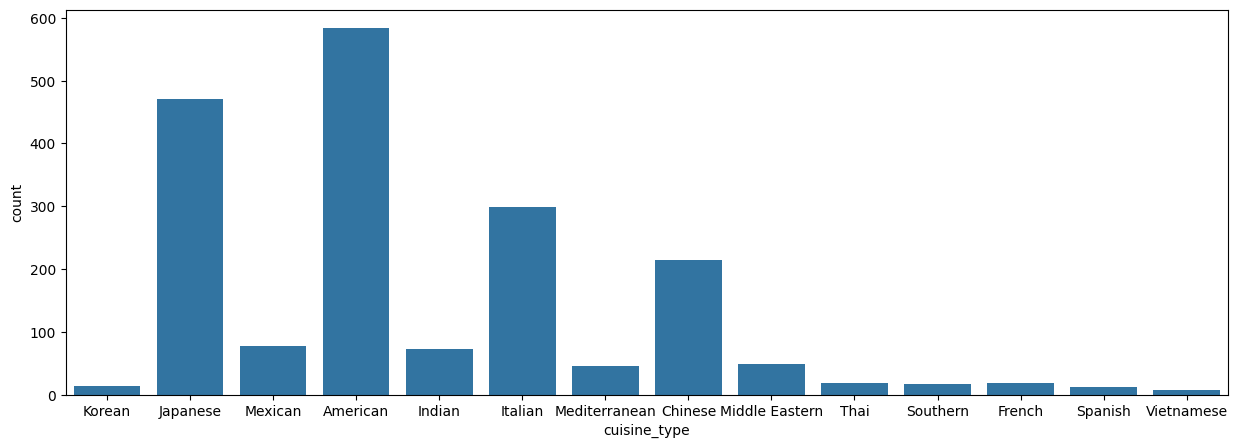

In [ ]:
# Create a bar graph for cuisine type
plt.figure(figsize = (15,5))
sns.countplot(data = df, x = 'cuisine_type')

**Observations:**
*   The most common cuisine type in the dataset is American, with approximately 580 orders.
*   Japanese and Italian are the second and third most common cuisines, with approximately 470 and 300 orders, respectively.
*    Afterward, cuisines such as Chinese, Mexican, Mediterranean, and Middle Eastern are moderately represented, with approximately 220, 80, and 50 orders, respectively.
*   The least represented cuisines, including Thai, Southern, French, and Spanish cuisines, each have approximately 30 orders, whereas Vietnamese and Korean have approximately 20 orders. These could be considered niche type restaurants.
*   Overall, the distribution in the graph is highly skewed, as a few cuisines dominate while many others receive few orders.







#### Cost of the order

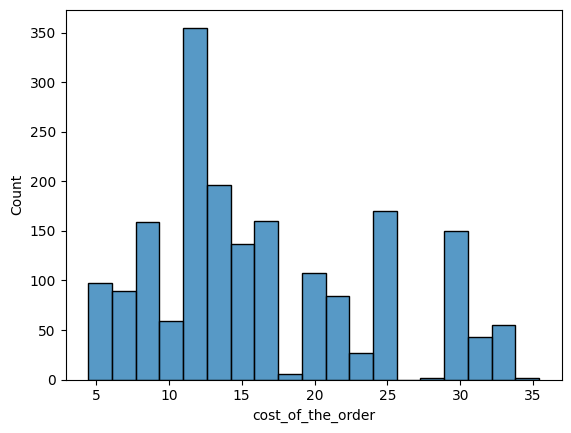

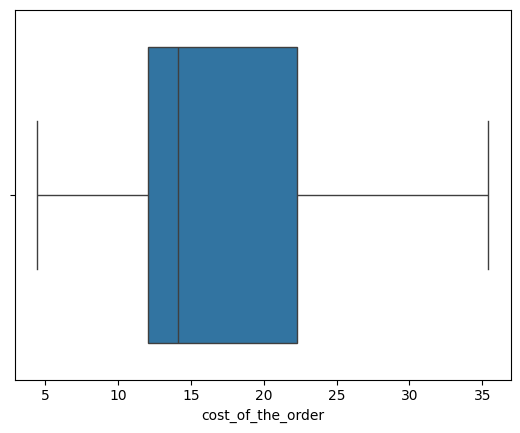

In [ ]:
#Plot Histogram for the cost of order
sns.histplot(data=df,x='cost_of_the_order') ## Histogram for the cost of order
plt.show()

#Create a boxplot for cost of order
sns.boxplot(data=df,x='cost_of_the_order') ## Boxplot for the cost of order
plt.show()

**Observations:**
*   The histogram shows that the distribution for cost of each order appears to be slightly right-skewed (positively skewed).
*   The histogram shows that the peak density is concentrated around the 10-15 range. Most orders cost \$10 to $15.
*   The histogram shows that there are some secondary peaks around \$25 and \$30, but they are smaller.
*   The boxplot also shows that the distribution appears slighlty right-skewed (positively skewed).
*   The median line shows closer to the bottom of the box (closer to Quartile 1 than Quartile 3).
*   The right whisker is longer than the left whisker, indicating a longer tail on the higher-cost side.


#### Day of the week

In [ ]:
# Check the unique values for day of the week
df['day_of_the_week'].unique()

array(['Weekend', 'Weekday'], dtype=object)

**Observations:**
*   For the given day of the week categorical variable, there are two unique values, which are Weekend and Weekday.
*   The dataset does not further differentiate, separate, or categorize the data to show individual days, such as Monday, Tuesday, Wednesday, Thursday, Friday, Saturday, and Sunday.



<Axes: xlabel='day_of_the_week', ylabel='count'>

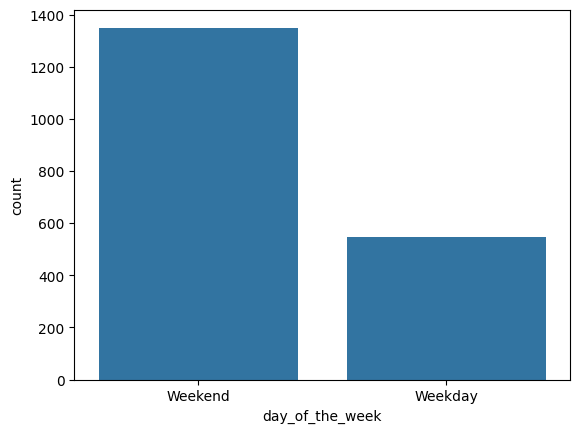

In [ ]:
#Plot bar graph for day of the week
sns.countplot(data = df, x = 'day_of_the_week')

**Observations:**
*   There is a weekend dominance present in the graph with orders close to 1400. This is about double the amount of orders during weekdays.
*   Thus, this suggests that the dataset is heavily skewed toward weekend activity.
*   Due to higher demand on weekends, this could be possibly due to leisure time, social gatherings, or dining out.
*   In contrast, the lower weekday demand could imply routine work schedules or less spending during weekdays.
*   The graph suggests more staffing availability, resource allocation, and marketing efforts should be enhanced for weekends.




#### Rating

In [ ]:
# Check the unique values for rating
df['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

**Observations:**
*   For the given rating variable, there are 4 unique values. They are ratings of "not given", "5," "3", and "4."
*   The dataset does not include unique rating values for "1" and "2."


<Axes: xlabel='rating', ylabel='count'>

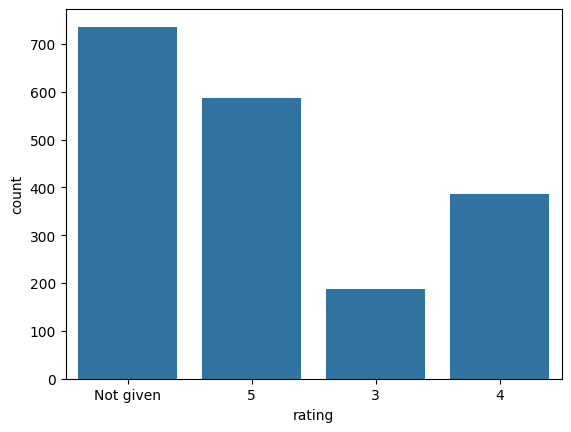

In [ ]:
#Plot bar graph for rating
sns.countplot(data = df, x = 'rating')

**Observations:**
*   The graph shows a high dominance of "not given" ratings, indicating a large proportion of customers or data points without a rating. This could imply missing data or a significant number of customers abstaining from leaving ratings.
*   A rating of "5" is the second most common, with around 600, suggesting a strong inclination toward high satisfaction or approval for customers who chose to leave a rating.
*   There are about 390 ratings of "4", indicating moderate satisfaction, but not being fully impressed.
*   The lowest rating, "3," indicates possibly neutral or slightly negative satisfaction from few customers.  
*   There is a positive bias, as ratings of "5" and "4" account for a substantial share of responses, suggesting favorable feedback.
*   There is a skewed distribution, with few "1" and "2" ratings and a majority of "5" ratings.


#### Food Preparation time

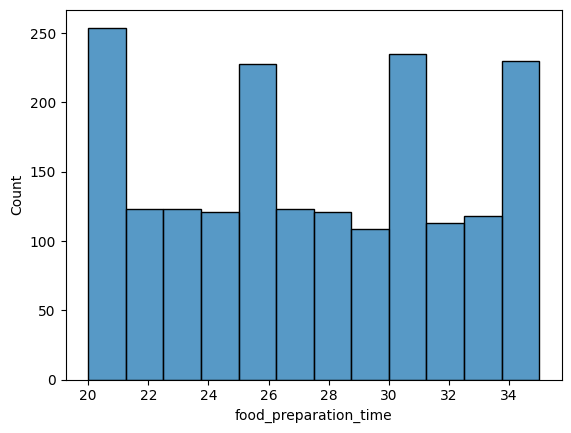

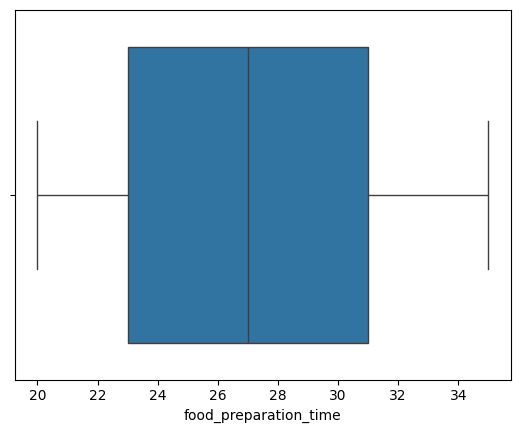

In [ ]:
#Plot histogram for food preparation time
sns.histplot(data=df,x='food_preparation_time') # Complete the code to plot the histogram for the cost of order
plt.show()

#Plot boxplot for food preparation time
sns.boxplot(data=df,x='food_preparation_time') # Complete the code to plot the boxplot for the cost of order
plt.show()

**Observations:**
*   The histogram shows that the distribution for food preparation time appears to be multimodal with several peaks, and fairly balanced.
*   The histogram shows that these multimodal peaks are noticeable showing around 20, 26, 30, and 34 minutes for food preparation times. They also suggest heterogeneous food preparation times, probably caused by different cuisines or specific food products.
*   The histogram shows that the distribution for food preparation time is not perfectly symmetric, as it shows multiple modes, suggesting that food preparation times cluster around several common durations.
*   This could reflect different types of meals or kitchen workflows.
*   The boxplot shows that the data is fairly symmetric, even though it is slightly right-skewed.
*   The IQR (Interquartile Range) shown in the boxplot indicates that the majority of food preparation times fall between 23 and 31 minutes.
*   There are also no extreme outliers present, but the whiskers suggest a wide spread.


#### Delivery time

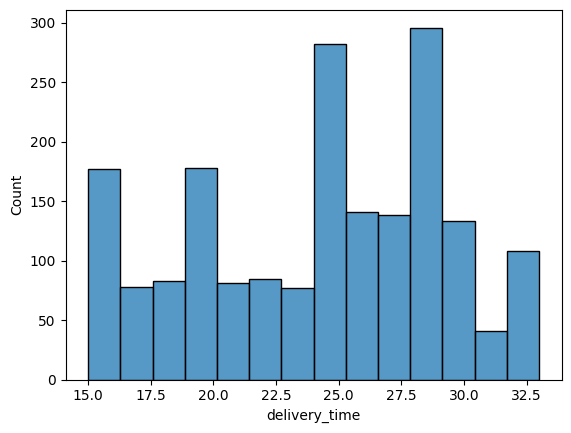

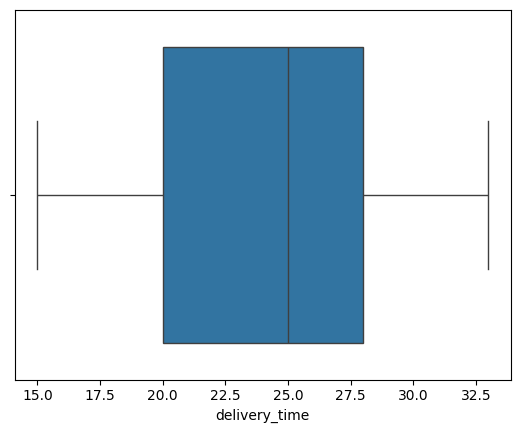

In [ ]:
#Plot histogram for delivery time
sns.histplot(data=df,x='delivery_time') # Complete the code to plot the histogram for the delivery time
plt.show()

#Plot boxplot for delivery time
sns.boxplot(data=df,x='delivery_time')  # Complete the code to plot the boxplot for the delivery time
plt.show()

**Observations:**
*   The histogram shows that the distribution for delivery time appears to be slightly right-skewed.
*   The histogram shows that there are noticeable multi structured peaks that cluster around 25 and 28 minutes.
*   The peaks also indicate that common delivery durations exceed beyond 28 minutes.
*   There is also a wide range spread in the histogram, suggesting high variability in service speed.
*   The boxplot shows that there is a central tendency of around 25 minutes.
*   The IQR (Interquartile Range – middle 50% of deliveries) is relatively tight, possibly suggesting consistent performance.
*   The whiskers reveal a moderate spread, but with no extreme outliers being visible.

### **Question 7:** Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Get top 5 restaurants with highest number of orders
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


**Observations:**
*    The top 5 restaurants by the number of orders received are Shake Shack (219), The Meatball Shop (132), Blue Ribbon Sushi (119), Blue Ribbon Fried Chicken (96), and Parm (68).
*   These restaurants may be outperforming others due to marketing or higher product quality.




### **Question 8:** Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Get most popular cuisine on weekends
df_weekend = df[df['day_of_the_week'] == 'Weekend']
df_weekend['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


**Observations:**
*   The most popular cuisine type on weekends is American with 415 orders.
*   This indicates a strong customer inclination of American-style restaurants.
*   American restaurants could contribute to the majority of overall revenue, as well as most customers demographics preferring American cuisine as opposed to other cuisine types.







### **Question 9:** What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Get orders that cost above 20 dollars
df_greater_than_20 = df[df['cost_of_the_order']>20]

# Calculate the number of total orders where the cost is above 20 dollars
print('The number of total orders that cost above 20 dollars is:', df_greater_than_20.shape[0])

# Calculate percentage of such orders in the dataset
percentage = (df_greater_than_20.shape[0] / df.shape[0]) * 100

print("Percentage of orders above 20 dollars:", round(percentage, 2), '%')

The number of total orders that cost above 20 dollars is: 555
Percentage of orders above 20 dollars: 29.24 %


**Observations**
*   As noted in the output, fewer than half of all orders cost above $20, with a percentage of 29.24%.
*   Conversely, the majority of orders in the dataset cost less than or equal to $20, with a percentage of 70.76%.
*   Restaurants with more than $20 in orders are significant contributers in optimizing revenue.
*   There should be available marketing stratgies to influence upselling or bundling to encourage customers in this bracket.
*   About 1 in 3 orders are high-value of above $20.




### **Question 10:** What is the mean order delivery time? [1 mark]

In [ ]:
# Get the mean delivery time
mean_del_time = df['delivery_time'].mean()

print('The mean delivery time for this dataset is', round(mean_del_time, 2), 'minutes')

The mean delivery time for this dataset is 24.16 minutes


**Observations:**
*   As noted in the output, the mean delivery time is approximately 24 minutes.
*   This finding implies that on average customers do not wait more than half an hour for their order to be delivered.
*   This mean delivery time could be considred typical and acceptable.




### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# Get the counts of each customer_id for top 3 frequent customers
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


**Observations:**
*  The top three most frequent customers eligible for 20% discount vouchers are the customers with IDs 52832, 47440, and 83287, with order amounts of 13, 10, and 9, respectively.
*   This implies that these customers are highly engaged, loyal, and project much satisfaction with the FoodHub food aggregator company.
*   Therefore, it is essential that they continue to contribute to the revenue for the overall company.



### Multivariate Analysis

### **Question 12:** Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]

#### Cuisine vs Cost of the order

/tmp/ipython-input-2537546578.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu')


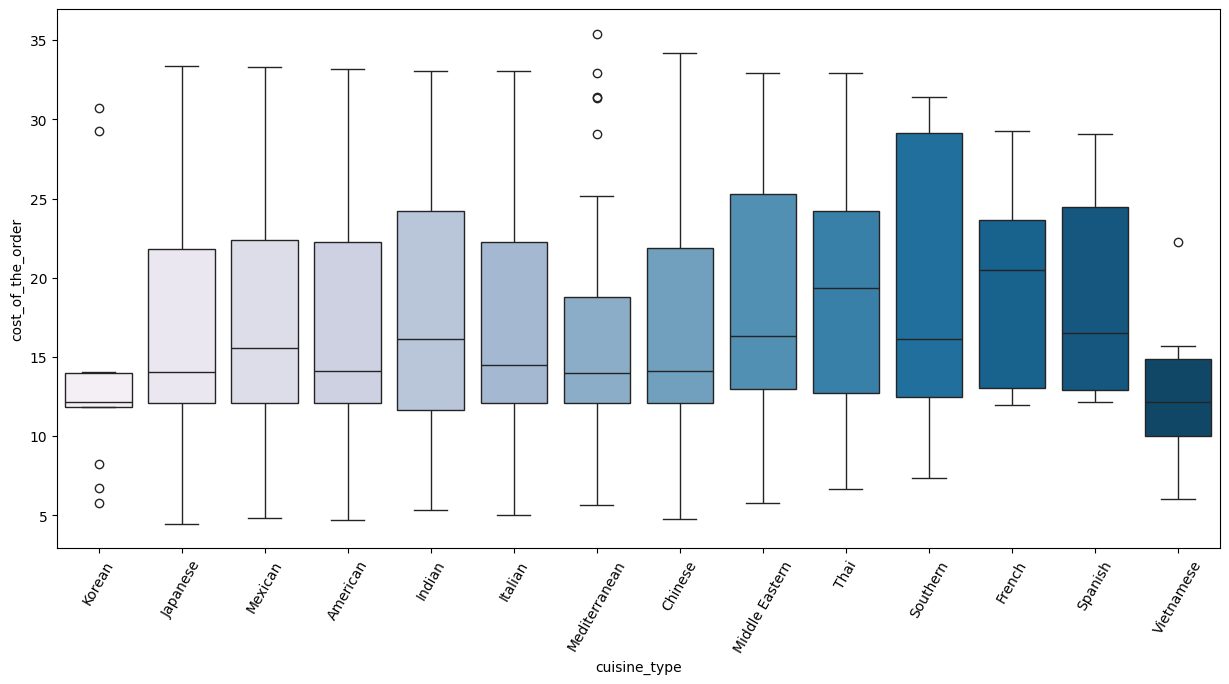

In [ ]:
# Plot boxplot to show relationship between cost of the order and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x = "cuisine_type", y = "cost_of_the_order", data = df, palette = 'PuBu')
plt.xticks(rotation = 60)
plt.show()

**Observations:**
*   Southern, Japanese, and French cuisines are higher-cost tier cuisines. Southern cuisine shows a higher median than most cuisines and a wider IQR, indicating higher prices of at most about $30 and greater variability. French and Japanese products show moderate to high medians of , possibly indicating premium options. These three cuisines also show evidence of higher-cost outliers, which could be due to specialty dishes or bundled orders.
*   Italian, Mediterranean, American, Mexican, and Indian cuisines are moderate-cost tier cuisines. Specifically, Italian, Mediterranean, and American cuisines have medians that are mid-range and are moderately spread in the data, suggesting balanced pricing for their products. As for Mexican and Indian cuisine, the data shows narrower interquartile ranges, suggesting consistent pricing across their products around a balanced median. American and Mexican shows have some outliers, possibly from large or customized orders.
*   Korean, Vietnamese, Middle Eastern, and Chinese cuisines are lower-cost tier cuisines. Korean and Vietnamese cuisines have low medians and narrow boxes, suggesting consistent, affordable prices for their products. Korean and Vietnamese cuisines appear to have few to no outliers, further reinforcing consistent pricing.
*   Furthermore, there are outlier data points visible for the following cuisines. There are three outlier points below the lower bound and past the minimum cost, and two outlier points above the maximum values for Korean cuisine. There are also several outlier data points for Mediterranean cuisine, all located above the upper bound, past the maximum value. Finally, one data point is considered an outlier for Vietnamese cuisine because it exceeds the upper bound.


#### Cuisine vs Food Preparation time

/tmp/ipython-input-197181710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df, palette='BrBG')  # Complete the code to visualize the relationship between food preparation time and cuisine type using boxplot


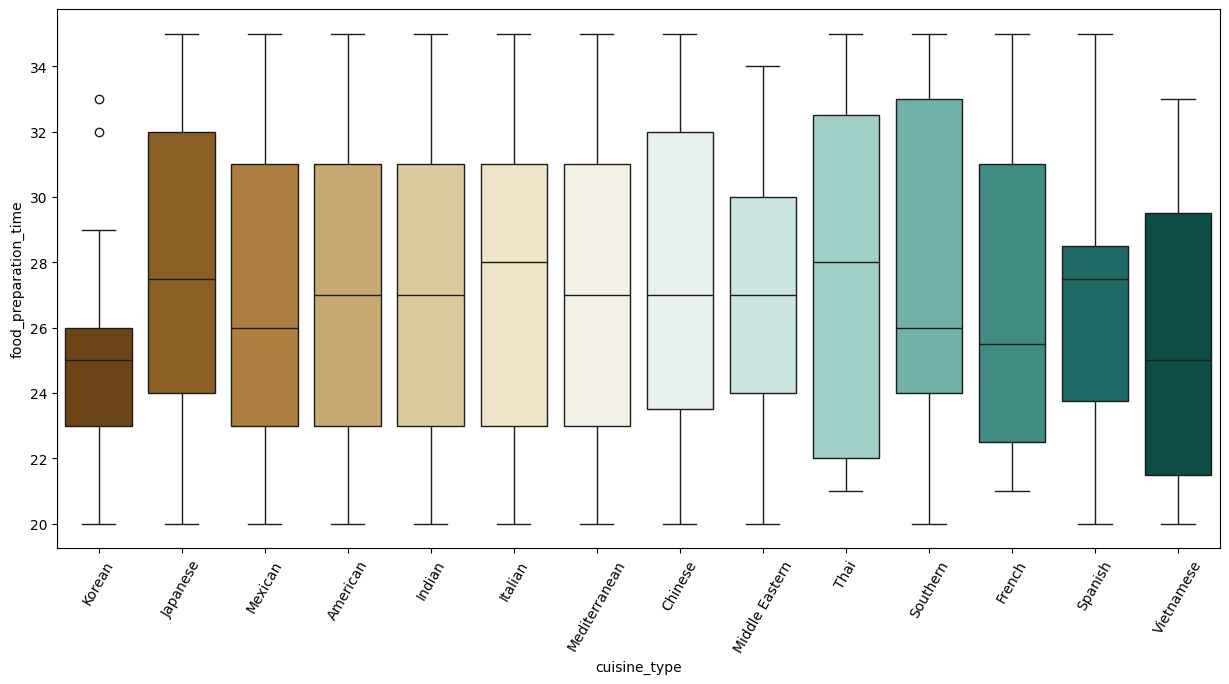

In [ ]:
# Plot boxplot to show relationship between food preparation time and cuisine type
plt.figure(figsize=(15,7))
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df, palette='BrBG')  # Complete the code to visualize the relationship between food preparation time and cuisine type using boxplot
plt.xticks(rotation = 60)
plt.show()

**Observations:**
*   Korean, Vietnamese, Middle Eastern, and Chinese cuisines are faster prep-tier cuisines. They show lower medians and tight interquartile ranges, indicating consistent shorter food preparation times. Middle Eastern and Chinese dishes also show faster food preparation times with little to no variability.
*   Mexican, American, Indian, and Mediterranean cuisines are moderate prep-tier cuisines. They have middle-range medians and compact boxes, which are generally predictable prep durations.
*   Japanese, French, Thai, and Southern cuisines are longest prep-tier cuisines. They display higher medians and wider interquartile ranges, which indicate longer variable food preparation times.
*   There are also two data point outliers visible above the upper bound, past the maximum value for Korean cuisine, suggesting that the food preparation time for those data points is possibly due to premium dish specialties, bundled orders, or fewer staff.


#### Day of the Week vs Delivery time

/tmp/ipython-input-3629065384.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_of_the_week', y='delivery_time', data=df, palette='RdBu')  # Complete the code to visualize the relationship between day of the week and delivery time using boxplot


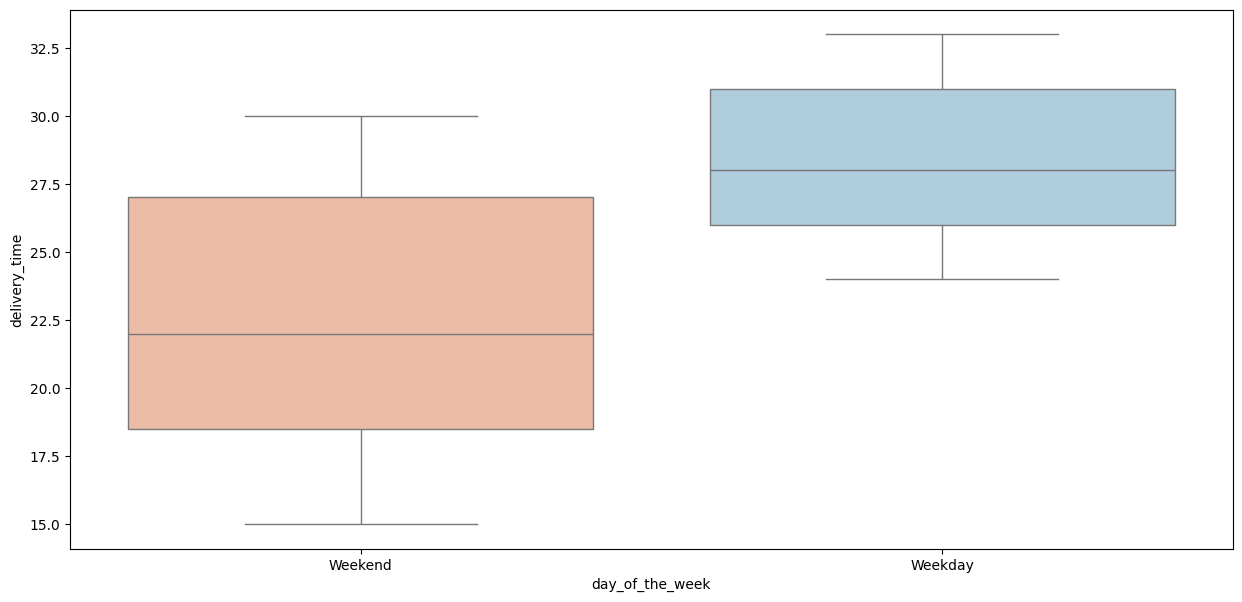

In [ ]:
#Plot boxplot to show relationship between day of the week and delivery time
plt.figure(figsize=(15,7))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df, palette='RdBu')  # Complete the code to visualize the relationship between day of the week and delivery time using boxplot
plt.show()


**Observations:**
*   Based on the Weekday boxplot, the median delivery time is substantially higher than on weekends. The whiskers for this boxplot indicate a longer delivery time window. It is possible to infer that weekday deliveries take longer than weekend deliveries, but they are more consistent and may take longer due to traffic caused by workday congestion.
*   Based on the Weekend boxplot, the median delivery time is substantially lower than on weekends. The whiskers for this boxplot indicate expansive variability. It is possible to infer that weekend deliveries are quicker on average due to more staffing across restaurants or equivocal demand.



#### Run the below code and write your observations on the revenue generated by the restaurants.

In [ ]:
#Generate table to show revenue generated by top 14 restaurants
df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending = False).head(14)

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76
RedFarm Broadway,965.13
RedFarm Hudson,921.21
TAO,834.50
Han Dynasty,755.29


**Observations:**
*   Based on the restaurant revenue table, Shake Shack is the leading top-performing restaurant in the entire dataset with $3,579.53 in revenue, approximately 67% higher than The Meatball Shop, the second most performing restaurant in revenue.
*   Aside from Shake Shack and The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken, and Parm are ranked in the top 3, 4, and 5 positions, respectively.
*   Restaurants ranking in the lower end of the table, such as Rubirosa and Five Guys Burgers and Fries, have modest total revenue amounts that could be due to fewer orders or lower average order value.
*  Based on the table, we can also infer that there might be a strong branding cluster relationship due to the name, Blue Ribbon, appearing multiple times in the table. In other words, this suggests that Blue Ribbon offers a variety of cuisines, including American and Japanese.
*  Likewise, some possible high spenders encompass American, Italian, and Asian cuisine, implying popular or premium menu items.
*  On another note, Shake Shack’s top revenue performance might be due to high customer traffic instead of high prices. In contrast, sushi dishes available in Asian restaurants may be due to higher-quality, exclusive food options.


#### Rating vs Delivery time

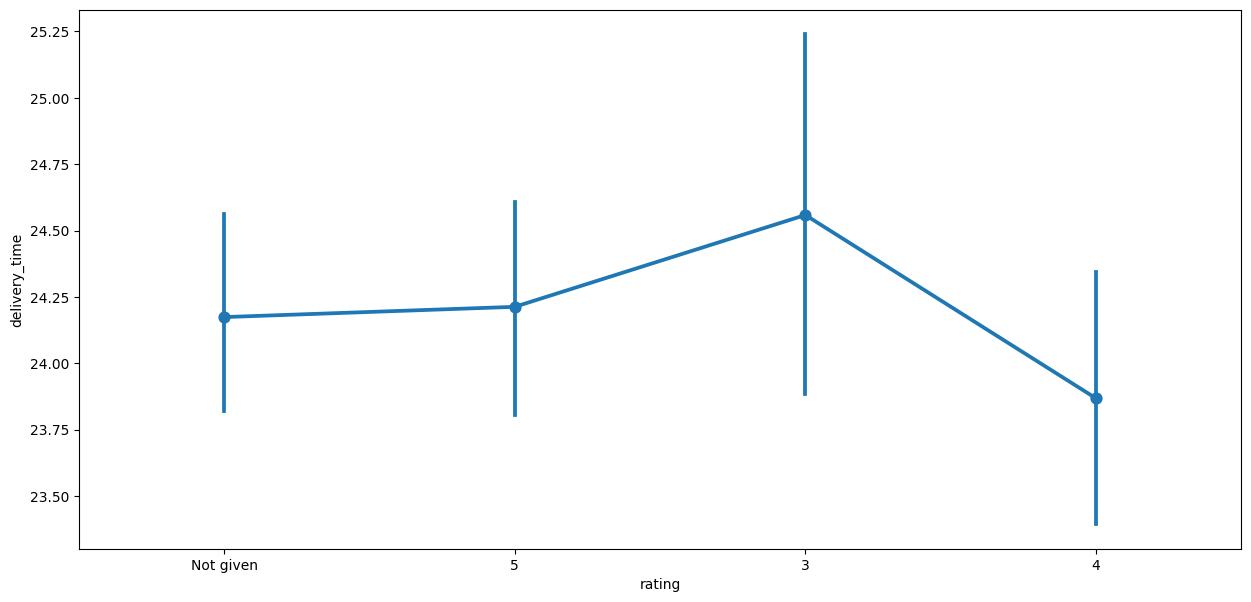

In [ ]:
#Plot pointplot to show relationship between rating and delivery time
plt.figure(figsize=(15, 7))
sns.pointplot(x = 'rating', y = 'delivery_time', data = df)
plt.show()

**Observations:**
* The rating vs. delivery time pointplot displays a trend where delivery time increments from a rating of “not given” to rating 3, and then decrements to rating 4.
* The pointplot further suggests that a rating of 3 is associated with slower delivery times, which could imply poor customer satisfaction or operational delays.
* When customers choose not to leave a rating, the pointplot displays fastest delivery times, which could be due to customers being passive or resorting to the default behavior of not preferring to leave a rating.


#### Rating vs Food preparation time

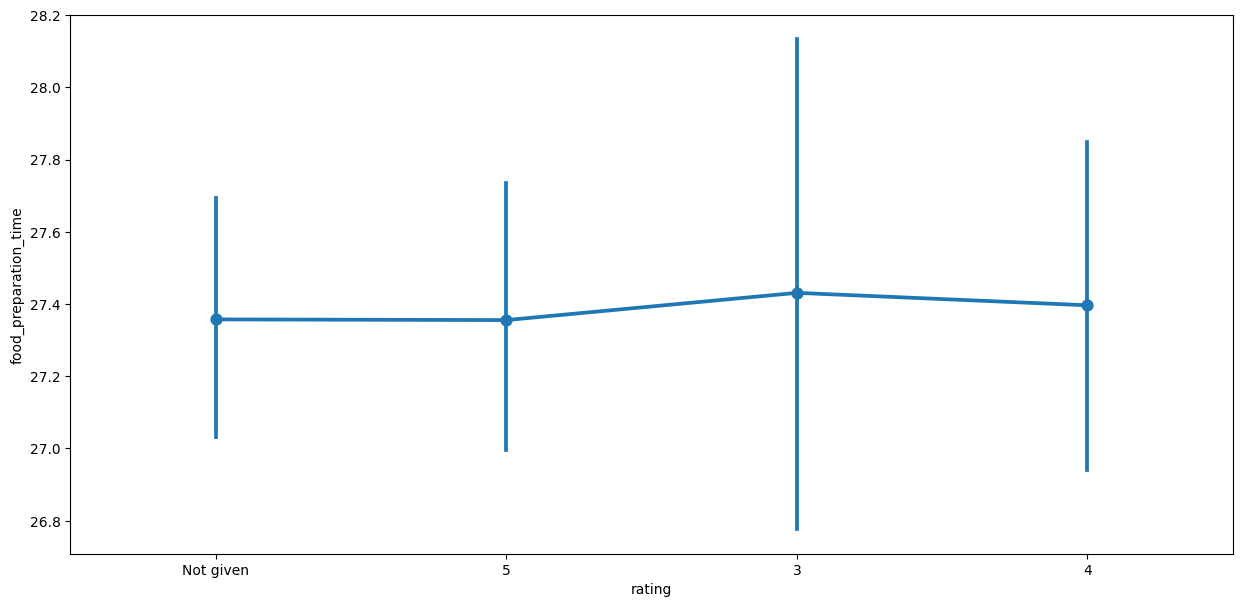

In [ ]:
#Plot pointplot to show relationship between rating and food preparation time
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating', y='food_preparation_time', data=df)
plt.show()

**Observations:**
* Similar to the previous rating vs. delivery time point plot, this rating vs. food preparation pointplot represents a trend where food preparation time increments from a rating of “not given” to rating 3, and then decrements to rating 4.
* Likewise, the pointplot further suggests that a rating of 3 is associated with slower food preparation times, which could imply poor customer satisfaction.
* In the same manner, when customers choose not to leave a rating, the pointplot displays the fastest food preparation times, which could be due to customers ordering simple orders or being less engaged with the rating process.



#### Rating vs Cost of the order

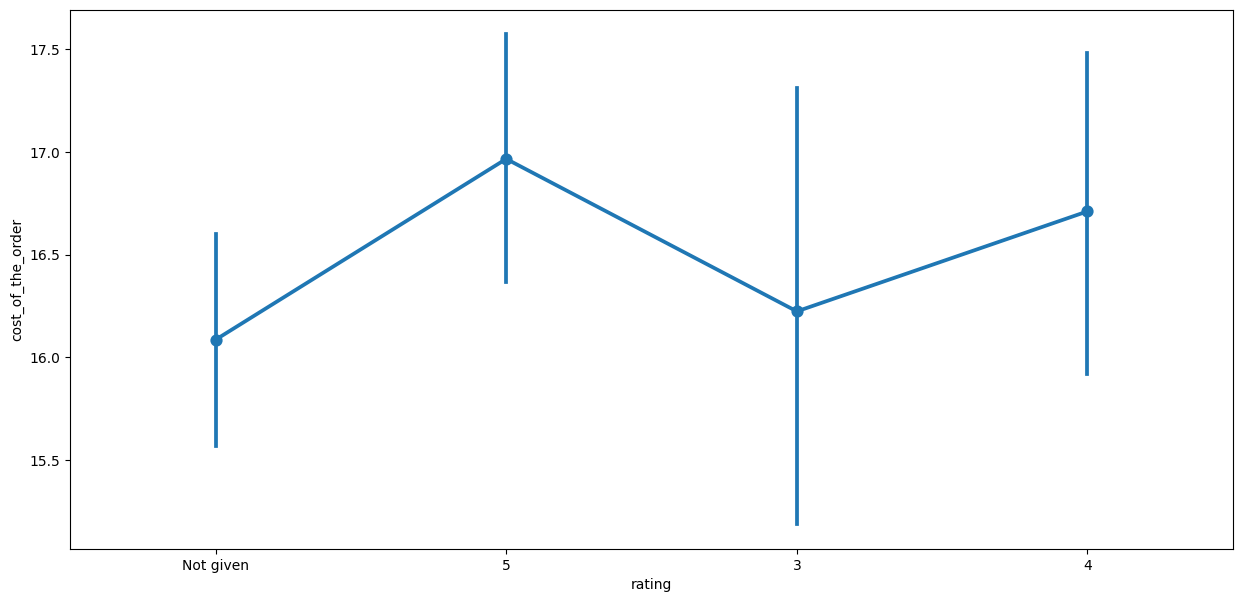

In [ ]:
# Plot pointplot to show relationship between rating and cost of the order
plt.figure(figsize=(15, 7))
sns.pointplot(x='rating', y='cost_of_the_order', data=df)
plt.show()

**Observations:**
* Similar to the previous rating vs. delivery time and rating vs. food preparation time pointplots, this rating vs. cost of order pointplot represents a trend where cost of order increments from a rating of “not given” to rating 3, and then decrements to rating 4.
* Foremost, a rating of 3 is associated with the highest average cost, which could imply that higher, more expensive orders do not always lead to high customer satisfaction.
* A “not given” rating corresponds to the cheapest costs across placed orders, which could imply lighter, smaller orders.  


#### Correlation among variables

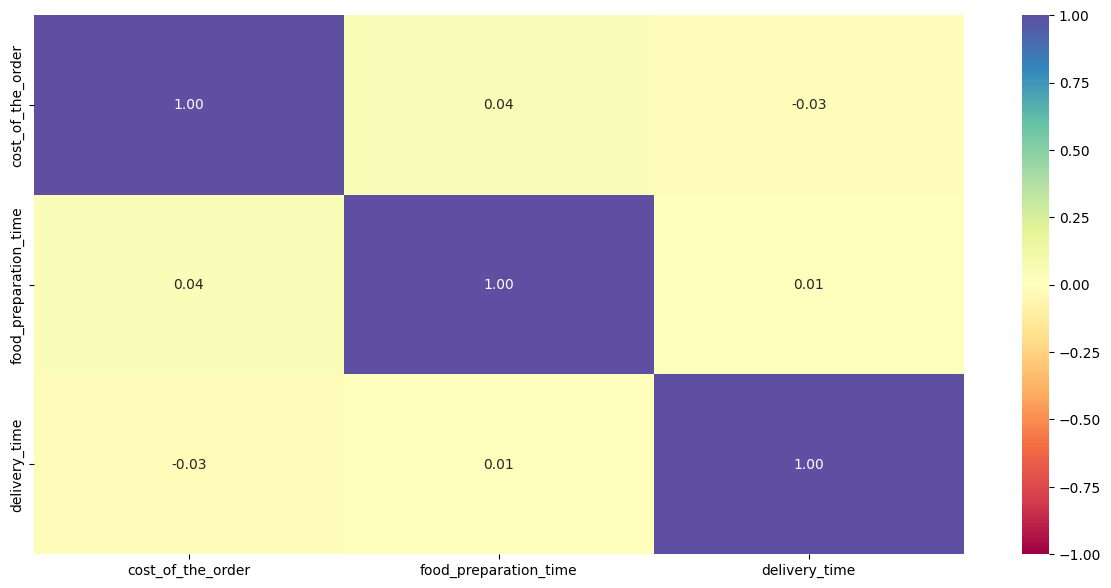

In [ ]:
# Plot heatmap to show correlations between cost of order, food preparation time, and delivery time
col_list = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
plt.figure(figsize=(15, 7))
sns.heatmap(df[col_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

**Observations:**
* The heatmap for the numerical variables in this dataset reveals that there is a slight positive correlation (e.g., +0.04 Pearson correlation coefficient) between the cost of orders and food preparation time. Thus, there is a direct positive correlation: more expensive orders take longer to prepare, but this relationship may be deemed imperceptible.
* The heatmap also shows a slight negative correlation (e.g., -0.03 Pearson correlation coefficient) between the cost of orders and delivery time. Thus, there is an inverse relationship: more expensive orders may be delivered more quickly, but this relationship may be deemed inconsequential.
* The heatmap further shows that there is a small positive correlation (e.g., +0.01 Pearson correlation coefficient) between food preparation time and delivery time. Thus, this could imply a non-meaningful relationship in which longer food preparation times do not reflect slower delivery times.



### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Filter the rated restaurants
df_rated = df[df['rating'] != 'Not given'].copy()

# Convert rating column from object to integer
df_rated['rating'] = df_rated['rating'].astype('int')

# Create a dataframe that contains the restaurant names with their rating counts
df_rating_count = df_rated.groupby(['restaurant_name'])['rating'].count().sort_values(ascending = False).reset_index()
df_rating_count.head()

,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64
4,RedFarm Broadway,41


In [ ]:
# Get the restaurant names that have rating count more than 50
rest_names = df_rating_count[df_rating_count['rating'] > 50]['restaurant_name'] # Complete the code to get the restaurant names having rating count more than 50

# Filter to get the data of restaurants that have rating count more than 50
df_mean_4 = df_rated[df_rated['restaurant_name'].isin(rest_names)].copy()

# Group and sort the restaurant names with their ratings and find the mean rating of each restaurant with descending mean ratings
df_mean_rating = df_mean_4.groupby(['restaurant_name'])['rating'].mean().sort_values(ascending = False).reset_index().dropna()

# Filter restaurants with average rating greater than 4
promotional_restaurants = df_mean_rating[df_mean_rating['rating'] > 4]

#print('The restaurants that are eligible for the promotional offer are:', promotional_restaurants)
print('restaurant_name', df_mean_rating, promotional_restaurants)

restaurant_name              restaurant_name    rating
0          The Meatball Shop  4.511905
1  Blue Ribbon Fried Chicken  4.328125
2                Shake Shack  4.278195
3          Blue Ribbon Sushi  4.219178              restaurant_name    rating
0          The Meatball Shop  4.511905
1  Blue Ribbon Fried Chicken  4.328125
2                Shake Shack  4.278195
3          Blue Ribbon Sushi  4.219178


**Observations:**
* The restaurants eligible for the promotional offer are The Meatball Shop, Blue Ribbon Fried Chicken, Shake Shack, and Blue Ribbon Sushi. The Meatball Shop has the highest average rating of 4.51, making it the standout candidate for a multitude of promotions.
* As earlier mentioned, the Blue Ribbon restaurants appear to be a brand, revealing a potent brand relationship across Blue Ribbon-named restaurants.
* These results align with the previous findings of the top five restaurants with the highest orders, which indicate that only the highest-performing restaurants qualify for this promotional offer.
* Surprisingly, The Meatball Shop and Blue Ribbon Fried Chicken restaurants have higher ratings than Shake Shack, even though they were previously ranked second and fourth, respectively, in having the most orders.
* Overall, all restaurants eligible for the promotion present consistently high-quality food products and customer satisfaction.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# Function to determine the revenue
def compute_rev(x):
    if x > 20:
        return x*0.25
    elif x > 5:
        return x*0.15
    else:
        return x*0

# Create a new column called revenue by calculating the revenue across restaurants using the cost each order
df['Revenue'] = df['cost_of_the_order'].apply(compute_rev)
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,Revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,1.7385


In [ ]:
# Get the total net revenue and print it
total_rev = df['Revenue'].sum() # Write the appropriate function to get the total revenue
print('The net revenue is around', round(total_rev, 2), 'dollars')

The net revenue is around 6166.3 dollars


**Observations**:

* The FoodHub food delivery company earned a total of about $6,166, which is a suitable revenue amount for the amount of data collected and present in the dataset.
* As the data was collected primarily showing week-time projections between weekdays and weekends, this suggests a strong performance.
* High-value orders greater than $20 contribute immensely due to the 25% commission rate. Mid-range orders between $5 and $20 contribute moderately, but at much lower levels. Lower-cost orders of less than $5 do not include a commission rate and do not contribute to overall revenue.
* It is preferred to encourage customers to make orders greater than $20 to optimize revenue due to higher commission rates. Promotions or staff competent in upselling could be used to influence higher-order purchases.
* Due to most orders clustering around $12 to $15 (as shown in the previous cost of order histogram), most revenue produced comes from the 15% commission tier.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]


In [ ]:
# Calculate total delivery time and add a new column to the dataframe df to store the total delivery time
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Write the code below to find the percentage of orders that have more than 60 minutes of total delivery time
# Get orders that take longer than 60 minutes to deliver
df_total_time_greater_than_60 = df[df['total_time'] > 60]

#Calculate the number of total orders that take longer than 60 minutes to deliver
print('The number of total orders that take more than 60 minutes to deliver is:', df_total_time_greater_than_60.shape[0])

#Calculate percentage of such orders in the dataset
percentage_V2 = (df_total_time_greater_than_60.shape[0] / df.shape[0]) * 100

print('Percentage of orders with delivery times longer than 60 minutes:', round(percentage_V2, 2), '%')


The number of total orders that take more than 60 minutes to deliver is: 200
Percentage of orders with delivery times longer than 60 minutes: 10.54 %


**Observations:**
* According to the output, 200 orders exceeded 60 minutes in total time (e.g., food preparation and delivery), which represents about 10% of all orders found in the dataset.
* There is an overall majority efficiency where nearly 90% of all orders have shorter delivery times of less than an hour. The Food Hub food delivery company is thus meeting standard customer expectations for the majority of orders.
* The 10.54% hindrance could be due to delays occurring, possibly due to complicated food preparation leading to longer food preparation times, overwhelming higher demand time periods occurring during weekdays and weekends, and complications caused by traffic, longer distance deliveries, and whether delivery employees are available to pick up and deliver orders at a given time and location to fulfill orders.
* Similar to longer food preparation and delivery times, orders that take longer than 60 minutes could influence lower ratings and unhappy customers.



### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# Get the mean delivery time on weekdays
print('The mean delivery time on weekdays is around',
      round(df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()),
     'minutes')

# Get the mean delivery time on weekends
print('The mean delivery time on weekends is around',
      round(df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()),
      'minutes')


The mean delivery time on weekdays is around 28 minutes
The mean delivery time on weekends is around 22 minutes


**Observations:**
* The output reveals that deliveries are faster on weekends as compared to weekdays, with a mean of 6 minutes quicker on weekends than on weekdays. In particular, weekend delivery times are 21% faster.
* Some inferences that could be made are that there is less traffic on the weekends, allowing delivery employees to pick up and deliver orders to customers quickly. Even though there are fewer orders on weekdays, as noted in a previous bar graph, there may be higher demand during office lunch periods or after work commutes when people have dinner. Another inference is that restaurants might have more employees on weekends than on weekdays. Additionally, customers are more likely to place smaller, less costly orders on weekends, which could lead to shorter food preparation and delivery times.
* Customer experience impact inferences, such as shorter delivery times during weekends, could improve overall satisfaction and ratings, whereas longer delivery times on weekdays could suggest lower ratings of 3, as shown in the earlier pointplot of ratings vs. delivery times.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  

### Recommendations:

*  

---